## Practical Homework 3: Neural Networks for Birdcall Classification 
#### Author: EJ Bergevin

### Setup

Start by importing our needed tool packages.

In [1]:
#data management
import pandas as pd
import numpy as np

#hdf5 large library management
#HDF5 (Hierarchical Data Format version 5) is an open-source file format and software library designed to 
#store, organize, and manage massive, complex, and heterogeneous scientific data
import h5py

#audio file management
import librosa
import librosa.display

#plotting
import matplotlib.pyplot as plt

In [310]:
#keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten, GlobalAveragePooling2D
from keras.datasets import mnist, cifar10
from keras.utils import to_categorical
from keras.applications.resnet import preprocess_input
from keras.applications import ResNet50
from keras.applications import imagenet_utils
from keras.callbacks import EarlyStopping

In [31]:
# sklearn for modeling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LassoCV, LogisticRegression
from sklearn.preprocessing import LabelBinarizer, StandardScaler
from sklearn.metrics import mean_absolute_error, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

Check our working directory, since we will be loading data from a HDF5 preprocessed file with spectrograms.

In [15]:
pwd

'C:\\Users\\ejber\\Desktop\\Grad\\Spring 26\\DATA 5322\\week 7\\Practical HW'

Load the file, and check the directory which is sorted by bird species.

In [16]:
f = h5py.File('bird_spectrograms.hdf5', 'r')
list(f.keys())

['amecro',
 'amerob',
 'bewwre',
 'bkcchi',
 'daejun',
 'houfin',
 'houspa',
 'norfli',
 'rewbla',
 'sonspa',
 'spotow',
 'whcspa']

Each subset by species has a different number of samples or spectrograms.

In [97]:
dset = f['amecro']
dset.shape

(128, 517, 66)

Our audio data has been saved for 3 seconds, with a sample rate of 22050 Hz (22.05 kHz), meaning that the audio was snapshotted 22,050 times per second. It was determined that a hop length of 128 snapshots and a window length of 512 snapshots was optimal. This means the first column of pixels in our spectogram should summarize the first 512 snapshots. Then we move forward 128 snapshots, and the second columnn of pixels will summarize the next 512 snapshots from there. There will be overlap between 512 snapshot groups! 22050 snapshots * 3 seconds / 128 snapshot hops creates appx 517 pixel columns, each summarizing 512 snapshots.

The "mel" value for y-axis transforms our data's reality of Fourier transformed frequencies in mel-scaled bands back into Hz. The bands themselves are not actually even across the Hz range.

In [25]:
sr = 22050
hl = 128

Peek at a single spectrogram from the data for the American crow, amecro. Hz is a frequency of air pressure variations (waves). Time here is in seconds.

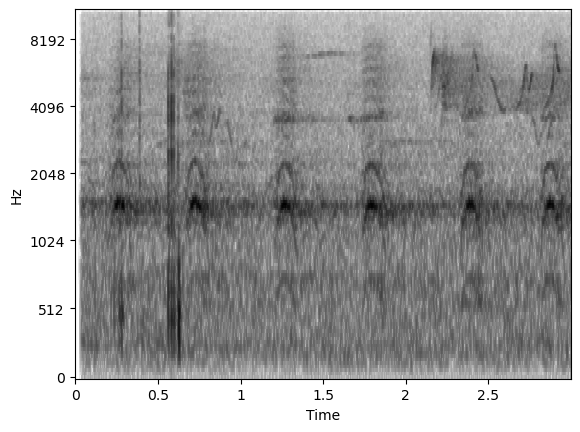

In [28]:
librosa.display.specshow(f['amecro'][:,:,10], x_axis='time', y_axis='mel', sr=sr, hop_length = hl , cmap='gray_r')

And we can see the values that are actually "coloring these pixels" like so; they are a matrix of 128 frequency bands by 517 timeframes. Each value in our matrix is 0 to -80. 0 is the loudest, most visible or audible. -80 is the clipped quietest value. This is determined by the librosa package defaults.

In [35]:
img = f['amecro'][:, :, 10]
img

array([[-80.        , -80.        , -80.        , ..., -50.95123672,
        -62.06111145, -50.05244827],
       [-80.        , -80.        , -80.        , ..., -49.29900742,
        -64.30673218, -49.72350311],
       [-80.        , -80.        , -80.        , ..., -47.84635544,
        -51.65913391, -44.85110474],
       ...,
       [-80.        , -80.        , -80.        , ..., -58.03029633,
        -60.27118301, -59.47906876],
       [-80.        , -80.        , -80.        , ..., -63.28816223,
        -62.83179092, -60.26020432],
       [-80.        , -80.        , -80.        , ..., -70.43822479,
        -69.76974487, -62.94641113]])

In [39]:
img.shape

(128, 517)

We can check the full count of our samples then to understand if it is reasonable to convert the file into a numpy array.

In [143]:
trec = 0
for lset in list(f.keys()):
    dset = f[lset]
    trec += dset.shape[2]
    print(lset, dset.shape[2])
trec

amecro 66
amerob 172
bewwre 144
bkcchi 45
daejun 125
houfin 84
houspa 630
norfli 37
rewbla 187
sonspa 263
spotow 137
whcspa 91


1981

This should be doable, so let's try it.

In [125]:
#start with lists
data = []
bird_spec = []

#for each species dataset
for i, key in enumerate(f.keys()): 
    # HDF5dataset[...] will read the HDF5dataset into a numpy array
    arr = f[key][...]

    #for each sample record
    for j in range(arr.shape[2]):
        #add the record to our data
        data.append(arr[:, :, j])
        #add the species (numerically) to our labels
        bird_spec.append(i)

X = np.array(data, dtype=np.float32)
y = np.array(bird_spec)

And we can confirm that the first records from the hdf5 is the first record in our numpy arrays.

In [98]:
dset[0] #this was amercro

array([[-46.88834381, -80.        , -64.68226624, ..., -80.        ,
        -80.        , -80.        ],
       [-43.3792572 , -80.        , -64.68226624, ..., -80.        ,
        -80.        , -80.        ],
       [-49.77828979, -80.        , -64.68226624, ..., -80.        ,
        -80.        , -80.        ],
       ...,
       [-29.16222   , -47.16543579, -25.50736237, ..., -37.45716095,
         -3.30982399, -11.87718391],
       [-28.30914497, -52.24941254, -21.86948013, ..., -36.7934494 ,
         -2.82069588,  -9.99111557],
       [-32.43891144, -35.52401733, -21.73007202, ..., -37.27110672,
         -4.69812775, -17.62159538]])

In [95]:
X[0]

array([[-46.888344, -43.379257, -49.77829 , ..., -29.16222 , -28.309145,
        -32.43891 ],
       [-42.22513 , -38.988407, -41.733604, ..., -27.011318, -25.279377,
        -29.90101 ],
       [-39.957607, -37.563396, -37.966076, ..., -27.631826, -24.20516 ,
        -29.968275],
       ...,
       [-72.94077 , -68.383644, -64.55382 , ..., -66.574745, -64.611626,
        -66.27029 ],
       [-77.05362 , -72.23953 , -72.752   , ..., -68.63258 , -67.04649 ,
        -67.9676  ],
       [-80.      , -80.      , -80.      , ..., -78.63836 , -76.75013 ,
        -75.59776 ]], dtype=float32)

In [126]:
y[0] #amercro should be 0 alphabetically, whcspa will be 11

0

We should scale values [-80,0] to the [0, 1] range so that parameters aren't wildly swinging. 

In [114]:
Xs = (X + 80) / 80

For American crow vs American robin binary classification, we cateogrize in 2.

In [150]:
y2 = y[y<2]
y2

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [151]:
len(y2)

238

In [153]:
X2s = Xs[0:len(y2)]
X2s

array([[[0.4138957 , 0.4577593 , 0.37777138, ..., 0.63547224,
         0.6461357 , 0.5945136 ],
        [0.4721859 , 0.5126449 , 0.47832996, ..., 0.6623585 ,
         0.68400776, 0.6262374 ],
        [0.5005299 , 0.53045756, 0.52542406, ..., 0.65460217,
         0.6974355 , 0.62539655],
        ...,
        [0.08824034, 0.14520445, 0.19307728, ..., 0.16781569,
         0.19235468, 0.17162141],
        [0.03682976, 0.09700584, 0.09060001, ..., 0.1420927 ,
         0.16191883, 0.15040502],
        [0.        , 0.        , 0.        , ..., 0.01702051,
         0.04062338, 0.05502796]],

       [[0.        , 0.        , 0.        , ..., 0.41043204,
         0.34688234, 0.5559498 ],
        [0.        , 0.        , 0.        , ..., 0.49720526,
         0.46432942, 0.53918934],
        [0.        , 0.        , 0.        , ..., 0.5548943 ,
         0.52469623, 0.5203751 ],
        ...,
        [0.05182314, 0.11496973, 0.09931307, ..., 0.39083022,
         0.41890764, 0.43236962],
        [0.0

In [154]:
len(X2s)

238

For 12 species categorization, we one hot the values of 0 to 11.

In [130]:
Y12 = to_categorical(y, 12)
Y12

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]])

We set a start size to minimize the training time.

In [184]:
start_fraction_12 = .25
start_faction_2 = 1

#index start size
iss2 = np.random.choice(range(len(y2))
                        , round(len(y2)*start_faction_2)
                        , replace=False)

iss12 = np.random.choice(range(len(y))
                        , round(len(y)*start_fraction_12)
                        , replace=False)

We split our data into train and test.

In [185]:
# split data into train and test for binary classification
X2_train, X2_test, y2_train, y2_test = train_test_split(Xs[iss2]
                                                    , y2[iss2]
                                                    , test_size=0.25
                                                    , random_state=0)

In [186]:
X2_train[0].shape

(128, 517)

In [187]:
X2_train

array([[[0.4138957 , 0.4577593 , 0.37777138, ..., 0.63547224,
         0.6461357 , 0.5945136 ],
        [0.4721859 , 0.5126449 , 0.47832996, ..., 0.6623585 ,
         0.68400776, 0.6262374 ],
        [0.5005299 , 0.53045756, 0.52542406, ..., 0.65460217,
         0.6974355 , 0.62539655],
        ...,
        [0.08824034, 0.14520445, 0.19307728, ..., 0.16781569,
         0.19235468, 0.17162141],
        [0.03682976, 0.09700584, 0.09060001, ..., 0.1420927 ,
         0.16191883, 0.15040502],
        [0.        , 0.        , 0.        , ..., 0.01702051,
         0.04062338, 0.05502796]],

       [[0.82575685, 0.81874835, 0.74242884, ..., 0.7804857 ,
         0.85328466, 0.8634531 ],
        [0.82740116, 0.843582  , 0.79124147, ..., 0.77862036,
         0.8588866 , 0.8283985 ],
        [0.8237772 , 0.8425687 , 0.7677175 , ..., 0.7370006 ,
         0.84733105, 0.7748207 ],
        ...,
        [0.4944366 , 0.53289324, 0.55967546, ..., 0.5599233 ,
         0.54127175, 0.47806317],
        [0.2

In [188]:
y2_train

array([0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1,
       0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       0, 1])

In [291]:
# split data into train and test for all species classification, starting small
X12i_train, X12i_test, y12i_train, y12i_test = train_test_split(Xs[iss12]
                                                    , Y12[iss12]
                                                    , test_size=0.25
                                                    , random_state=0)

In [292]:
X12i_train

array([[[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.10074282],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.10338268],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.10472975],
        ...,
        [0.        , 0.        , 0.        , ..., 0.20240465,
         0.2113975 , 0.20265798],
        [0.        , 0.        , 0.        , ..., 0.12580815,
         0.16628294, 0.21041374],
        [0.        , 0.        , 0.        , ..., 0.03019657,
         0.05005293, 0.11811228]],

       [[0.        , 0.        , 0.        , ..., 0.01951199,
         0.11726856, 0.32762313],
        [0.        , 0.        , 0.        , ..., 0.11463251,
         0.1455226 , 0.34177312],
        [0.        , 0.        , 0.        , ..., 0.17794819,
         0.25676718, 0.35570544],
        ...,
        [0.        , 0.        , 0.00328951, ..., 0.46833572,
         0.45781785, 0.48089013],
        [0. 

In [293]:
y12i_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]])

In [294]:
# split data into train and test for all species classification, full data body
X12_train, X12_test, y12_train, y12_test = train_test_split(Xs
                                                    , Y12
                                                    , test_size=0.25
                                                    , random_state=0)

### Model Binary for American Crow vs American Robin
We are attempting a convolution network in that these are adept at determining 2D features spatially by utilizing a kernel and sliding across our spectrograms.

In [267]:
model_2cnn = Sequential(
    [
    #start with first round of 32 filters post input
    #padding = same means output has same dimension of input
    Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu', input_shape=(128,517,1)),
    #first pooling to summarize the finding of the filter
    MaxPooling2D(pool_size=(2,2)),
    #then add second round of larger body of filters
    Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'),
    #second pooling
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    #percent of nodes at each level to randomly ignore, prevents overfitting
    Dropout(rate=0.5),
    #final decision layer to determine most likely category
    Dense(units=1, activation='sigmoid')
    ])

model_2cnn.summary()

C:\Users\ejber\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_42 (Conv2D)              │ (None, 128, 517, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_42 (MaxPooling2D) │ (None, 64, 258, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 64, 258, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_43 (MaxPooling2D) │ (None, 32, 129, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 264192)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 264192)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │       264,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 283,009 (1.08 MB)

 Trainable params: 283,009 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

In [268]:
# compiling the neural network model -- not fitting!
# note that the loss function we optimze over does not have to be same metric we report upon completion 
# however, loss function should be specific to the problem -- regression is not same as binary classification
# the rmsprop optimizer option specifies a certain kind of gradient descent to lead the learning in the correct direction as we tune parameters
model_2cnn.compile(loss='binary_crossentropy',
              optimizer='rmsprop',
              metrics=['accuracy'])

In [269]:
%%time

history_2cnn = model_2cnn.fit(X2_train, y2_train,
    epochs=10,  #repeat attempts over full dataset
    batch_size=32, #number of sample images used per gradient update in the back propogation after measuring loss
    validation_split=0.2 #this is the amount of our training data that we are checking our loss against
    # ,verbose=0 #don't print anything
    )

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 307ms/step - accuracy: 0.6479 - loss: 2.3869 - val_accuracy: 0.7500 - val_loss: 0.5345
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 305ms/step - accuracy: 0.6620 - loss: 0.6661 - val_accuracy: 0.7500 - val_loss: 0.5514
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 310ms/step - accuracy: 0.7394 - loss: 0.5960 - val_accuracy: 0.7500 - val_loss: 0.5247
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 316ms/step - accuracy: 0.7183 - loss: 0.6011 - val_accuracy: 0.7500 - val_loss: 0.5593
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 279ms/step - accuracy: 0.7394 - loss: 0.5473 - val_accuracy: 0.7500 - val_loss: 0.5581
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 302ms/step - accuracy: 0.7394 - loss: 0.5064 - val_accuracy: 0.7500 - val_loss: 0.5024
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 309ms/step - accuracy: 0.7394 - loss: 0.5636 - val_accuracy: 0.7500 - val_loss: 0.4904
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 303ms/step - accuracy: 0.7606 - loss: 0.4888 - val_accuracy: 0.7778 - val_loss:

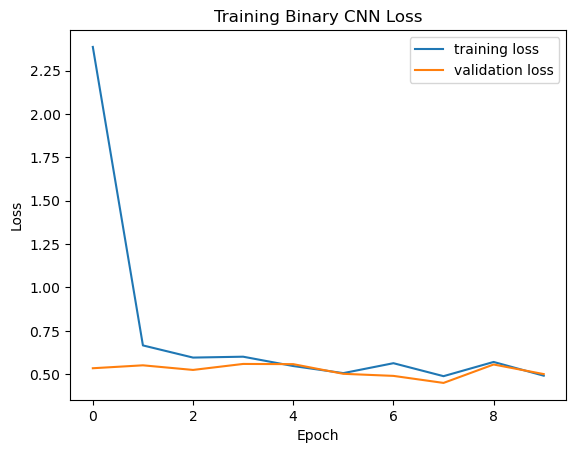

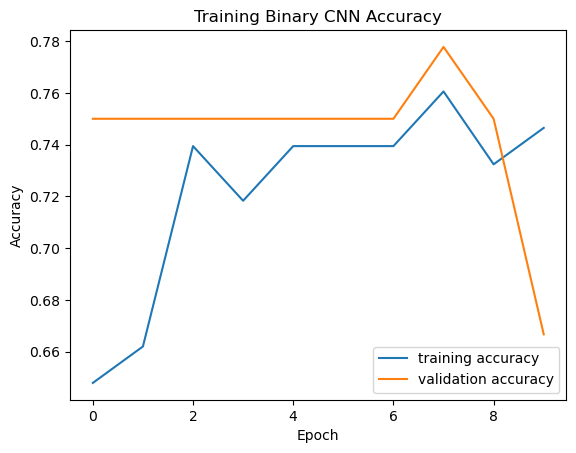

In [270]:
plt.plot(history_2cnn.history['loss'])
plt.plot(history_2cnn.history['val_loss'])
plt.title('Training Binary CNN Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['training loss', 'validation loss'], loc='upper right')
plt.show();

plt.plot(history_2cnn.history['accuracy'])
plt.plot(history_2cnn.history['val_accuracy'])
plt.title('Training Binary CNN Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['training accuracy', 'validation accuracy'], loc='lower right')
plt.show();

In [271]:
model_2cnn_4conv = Sequential(
    [
    Conv2D(filters=8, kernel_size=(3,3), padding='same', activation='relu', input_shape=(128,517,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=16, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dropout(rate=0.5),
    Dense(units=1, activation='sigmoid')
    ])

model_2cnn_4conv.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_44 (Conv2D)              │ (None, 128, 517, 8)    │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_44 (MaxPooling2D) │ (None, 64, 258, 8)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 64, 258, 16)    │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_45 (MaxPooling2D) │ (None, 32, 129, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 32, 129, 32)    │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_46 (MaxPooling2D) │ (None, 16, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 16, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_47 (MaxPooling2D) │ (None, 8, 32, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │        16,385 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,769 (159.25 KB)

 Trainable params: 40,769 (159.25 KB)

 Non-trainable params: 0 (0.00 B)

In [272]:
model_2cnn_4conv.compile(loss='binary_crossentropy',
              optimizer='rmsprop',
              metrics=['accuracy'])

In [273]:
%%time

history_2cnn_4conv = model_2cnn_4conv.fit(X2_train, y2_train,
    epochs=10,  #repeat attempts over full dataset
    batch_size=64, #number of sample images used per gradient update in the back propogation after measuring loss
    validation_split=0.2 #this is the amount of our training data that we are checking our loss against
    # ,verbose=0 #don't print anything
    )

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 266ms/step - accuracy: 0.7254 - loss: 0.7906 - val_accuracy: 0.5833 - val_loss: 0.6831
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.6056 - loss: 0.6662 - val_accuracy: 0.7500 - val_loss: 0.5403
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.7394 - loss: 0.5786 - val_accuracy: 0.7500 - val_loss: 0.5467
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.7394 - loss: 0.6254 - val_accuracy: 0.7500 - val_loss: 0.5206
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.7394 - loss: 0.5647 - val_accuracy: 0.8056 - val_loss: 0.6267
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.7465 - loss: 0.5938 - val_accuracy: 0.7500 - val_loss: 0.5105
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.7394 - loss: 0.5395 - val_accuracy: 0.8333 - val_loss: 0.5881
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.7746 - loss: 0.5457 - val_accuracy: 0.7500 - val_loss:

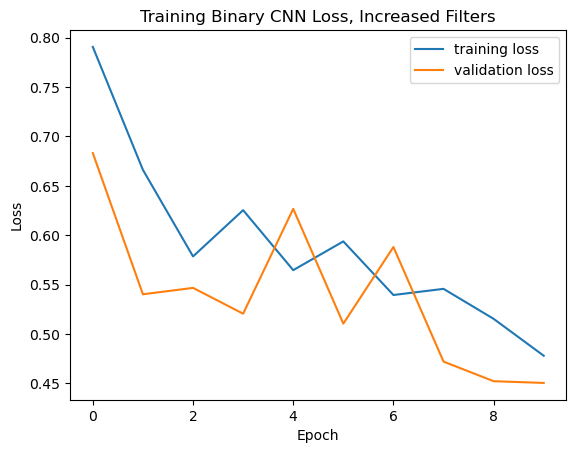

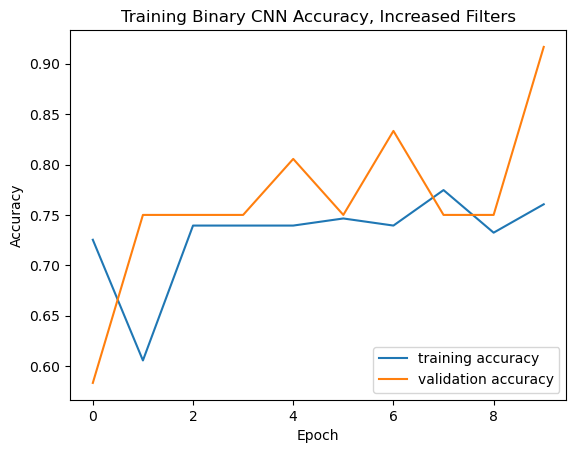

In [274]:
clarifier = "Increased Filters"

plt.plot(history_2cnn_4conv.history['loss'])
plt.plot(history_2cnn_4conv.history['val_loss'])
plt.title('Training Binary CNN Loss, ' +  clarifier)
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['training loss', 'validation loss'], loc='upper right')
plt.show();

plt.plot(history_2cnn_4conv.history['accuracy'])
plt.plot(history_2cnn_4conv.history['val_accuracy'])
plt.title('Training Binary CNN Accuracy, ' +  clarifier)
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['training accuracy', 'validation accuracy'], loc='lower right')
plt.show();

In [276]:
model_2cnn_4conv_30ep = Sequential(
    [
    Conv2D(filters=8, kernel_size=(3,3), padding='same', activation='relu', input_shape=(128,517,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=16, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dropout(rate=0.5),
    Dense(units=1, activation='sigmoid')
    ])

In [277]:
model_2cnn_4conv_30ep.compile(loss='binary_crossentropy',
              optimizer='rmsprop',
              metrics=['accuracy'])

In [278]:
%%time

history_2cnn_4conv_30ep = model_2cnn_4conv_30ep.fit(X2_train, y2_train,
    epochs=30,  #repeat attempts over full dataset
    batch_size=64, #number of sample images used per gradient update in the back propogation after measuring loss
    validation_split=0.2 #this is the amount of our training data that we are checking our loss against
    # ,verbose=0 #don't print anything
    )

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 254ms/step - accuracy: 0.5845 - loss: 0.6774 - val_accuracy: 0.7500 - val_loss: 0.6074
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.7394 - loss: 0.6143 - val_accuracy: 0.7500 - val_loss: 0.5738
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.7394 - loss: 0.5834 - val_accuracy: 0.7500 - val_loss: 0.5804
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.7394 - loss: 0.6122 - val_accuracy: 0.7500 - val_loss: 0.5520
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.7394 - loss: 0.5952 - val_accuracy: 0.7500 - val_loss: 0.5510
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.7394 - loss: 0.5774 - val_accuracy: 0.7500 - val_loss: 0.5481
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.7394 - loss: 0.5708 - val_accuracy: 0.7500 - val_loss: 0.5736
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.7394 - loss: 0.5840 - val_accuracy: 0.7500 - val_loss:

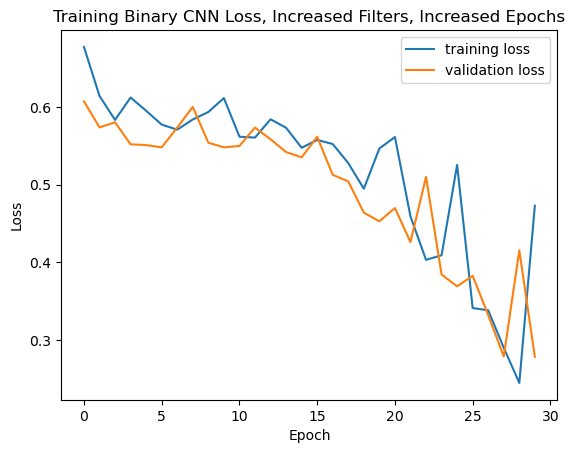

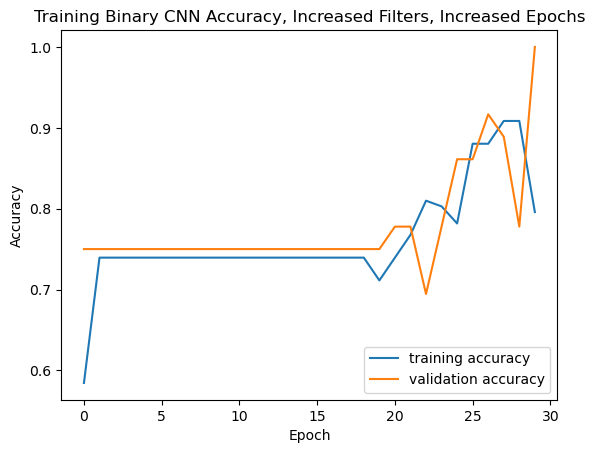

In [279]:
clarifier = "Increased Filters, Increased Epochs"

plt.plot(history_2cnn_4conv_30ep.history['loss'])
plt.plot(history_2cnn_4conv_30ep.history['val_loss'])
plt.title('Training Binary CNN Loss, ' +  clarifier)
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['training loss', 'validation loss'], loc='upper right')
plt.show();

plt.plot(history_2cnn_4conv_30ep.history['accuracy'])
plt.plot(history_2cnn_4conv_30ep.history['val_accuracy'])
plt.title('Training Binary CNN Accuracy, ' +  clarifier)
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['training accuracy', 'validation accuracy'], loc='lower right')
plt.show();

In [280]:
model_2cnn_4conv_30ep_halfval = Sequential(
    [
    Conv2D(filters=8, kernel_size=(3,3), padding='same', activation='relu', input_shape=(128,517,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=16, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dropout(rate=0.5),
    Dense(units=1, activation='sigmoid')
    ])

model_2cnn_4conv_30ep_halfval.compile(loss='binary_crossentropy',
              optimizer='rmsprop',
              metrics=['accuracy'])

In [281]:
%%time

history_2cnn_4conv_30ep_halfval = model_2cnn_4conv_30ep_halfval.fit(X2_train, y2_train,
    epochs=30,  #repeat attempts over full dataset
    batch_size=64, #number of sample images used per gradient update in the back propogation after measuring loss
    validation_split=0.5 #this is the amount of our training data that we are checking our loss against
    # ,verbose=0 #don't print anything
    )

Epoch 1/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 377ms/step - accuracy: 0.7303 - loss: 0.6327 - val_accuracy: 0.7528 - val_loss: 0.6140
Epoch 2/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.7303 - loss: 0.6100 - val_accuracy: 0.7528 - val_loss: 0.5946
Epoch 3/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.7303 - loss: 0.5991 - val_accuracy: 0.7528 - val_loss: 0.6140
Epoch 4/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.7303 - loss: 0.6088 - val_accuracy: 0.7528 - val_loss: 0.5547
Epoch 5/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.7303 - loss: 0.6395 - val_accuracy: 0.7528 - val_loss: 0.5493
Epoch 6/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.7303 - loss: 0.5805 - val_accuracy: 0.7528 - val_loss: 0.5556
Epoch 7/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.7303 - loss: 0.5771 - val_accuracy: 0.7528 - val_loss: 0.5719
Epoch 8/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.7303 - loss: 0.5932 - val_accuracy: 0.7528 - val_loss:

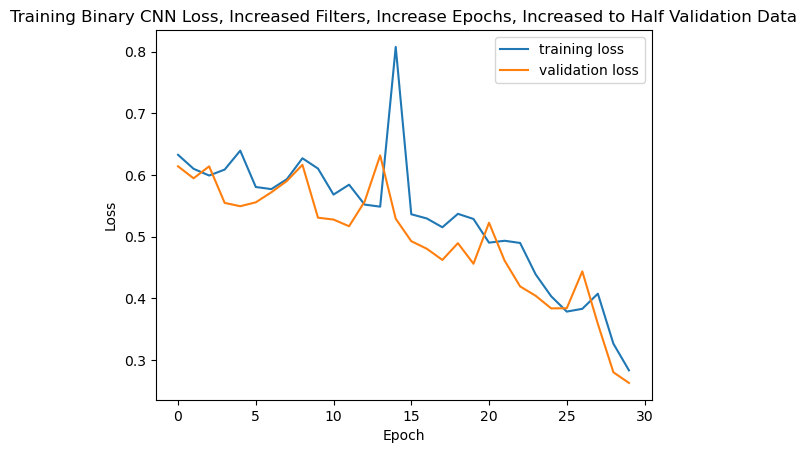

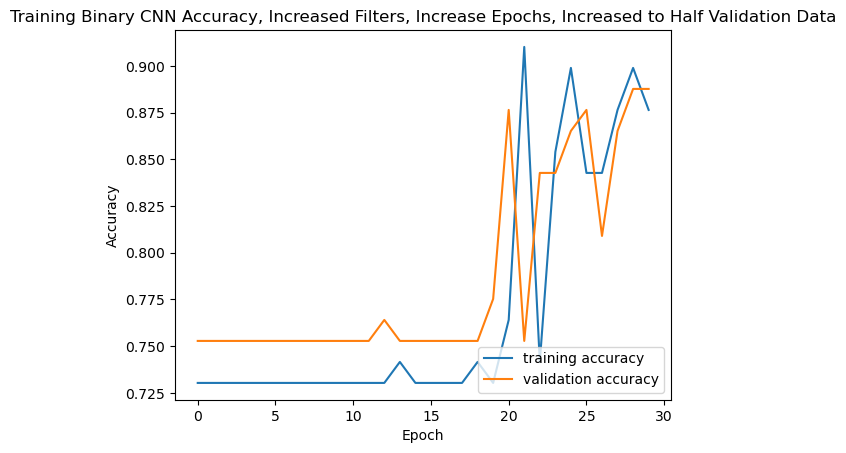

In [282]:
clarifier = "Increased Filters, Increase Epochs, Increased to Half Validation Data"

plt.plot(history_2cnn_4conv_30ep_halfval.history['loss'])
plt.plot(history_2cnn_4conv_30ep_halfval.history['val_loss'])
plt.title('Training Binary CNN Loss, ' +  clarifier)
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['training loss', 'validation loss'], loc='upper right')
plt.show();

plt.plot(history_2cnn_4conv_30ep_halfval.history['accuracy'])
plt.plot(history_2cnn_4conv_30ep_halfval.history['val_accuracy'])
plt.title('Training Binary CNN Accuracy, ' +  clarifier)
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['training accuracy', 'validation accuracy'], loc='lower right')
plt.show();

In [283]:
%%time

model_2cnn_5conv_100ep_halfval = Sequential(
    [
    Conv2D(filters=4, kernel_size=(3,3), padding='same', activation='relu', input_shape=(128,517,1)), 
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=8, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=16, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dropout(rate=0.5),
    Dense(units=1, activation='sigmoid')
    ])

model_2cnn_5conv_100ep_halfval.compile(loss='binary_crossentropy',
              optimizer='rmsprop',
              metrics=['accuracy'])

history_2cnn_5conv_100ep_halfval = model_2cnn_5conv_100ep_halfval.fit(X2_train, y2_train,
    epochs=100,  #repeat attempts over full dataset
    batch_size=64, #number of sample images used per gradient update in the back propogation after measuring loss
    validation_split=0.5 #this is the amount of our training data that we are checking our loss against
    ,verbose=0 #don't print anything
    )

model_2cnn_5conv_100ep_halfval.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_60 (Conv2D)              │ (None, 128, 517, 4)    │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_60 (MaxPooling2D) │ (None, 64, 258, 4)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_61 (Conv2D)              │ (None, 64, 258, 8)     │           296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_61 (MaxPooling2D) │ (None, 32, 129, 8)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_62 (Conv2D)              │ (None, 32, 129, 16)    │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_62 (MaxPooling2D) │ (None, 16, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_63 (Conv2D)              │ (None, 16, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_63 (MaxPooling2D) │ (None, 8, 32, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_64 (Conv2D)              │ (None, 8, 32, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_64 (MaxPooling2D) │ (None, 4, 16, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_17 (Flatten)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,476 (224.52 KB)

 Trainable params: 28,737 (112.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 28,739 (112.27 KB)

CPU times: total: 2min 1s
Wall time: 31.2 s


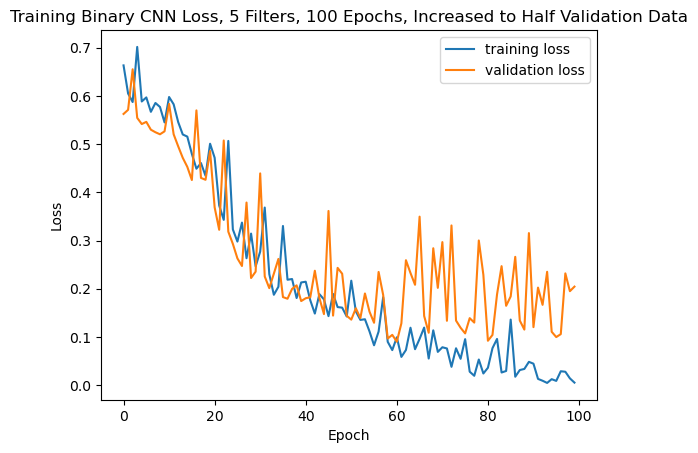

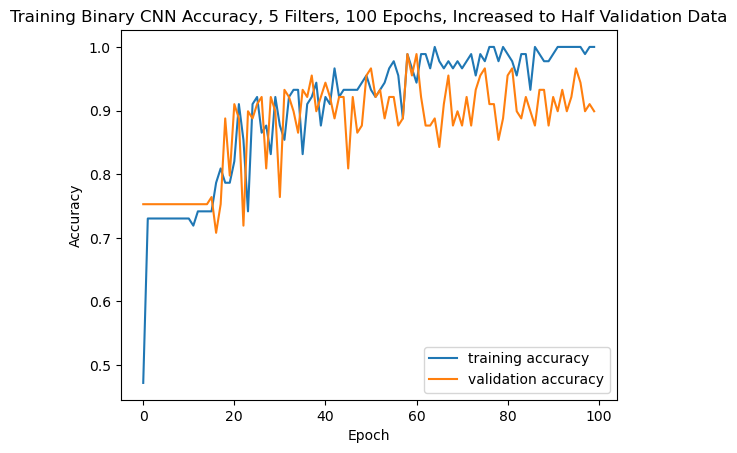

In [284]:
clarifier = "5 Filters, 100 Epochs, Increased to Half Validation Data"

plt.plot(history_2cnn_5conv_100ep_halfval.history['loss'])
plt.plot(history_2cnn_5conv_100ep_halfval.history['val_loss'])
plt.title('Training Binary CNN Loss, ' +  clarifier)
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['training loss', 'validation loss'], loc='upper right')
plt.show();

plt.plot(history_2cnn_5conv_100ep_halfval.history['accuracy'])
plt.plot(history_2cnn_5conv_100ep_halfval.history['val_accuracy'])
plt.title('Training Binary CNN Accuracy, ' +  clarifier)
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['training accuracy', 'validation accuracy'], loc='lower right')
plt.show();

In [285]:
%%time

model_2cnn_5conv_100ep_quartval = Sequential(
    [
    Conv2D(filters=4, kernel_size=(3,3), padding='same', activation='relu', input_shape=(128,517,1)), 
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=8, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=16, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dropout(rate=0.5),
    Dense(units=1, activation='sigmoid')
    ])

model_2cnn_5conv_100ep_quartval.compile(loss='binary_crossentropy',
              optimizer='rmsprop',
              metrics=['accuracy'])

history_2cnn_5conv_100ep_quartval = model_2cnn_5conv_100ep_quartval.fit(X2_train, y2_train,
    epochs=100,  #repeat attempts over full dataset
    batch_size=64, #number of sample images used per gradient update in the back propogation after measuring loss
    validation_split=0.25 #this is the amount of our training data that we are checking our loss against
    ,verbose=0 #don't print anything
    )

model_2cnn_5conv_100ep_quartval.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_65 (Conv2D)              │ (None, 128, 517, 4)    │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_65 (MaxPooling2D) │ (None, 64, 258, 4)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_66 (Conv2D)              │ (None, 64, 258, 8)     │           296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_66 (MaxPooling2D) │ (None, 32, 129, 8)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_67 (Conv2D)              │ (None, 32, 129, 16)    │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_67 (MaxPooling2D) │ (None, 16, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_68 (Conv2D)              │ (None, 16, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_68 (MaxPooling2D) │ (None, 8, 32, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_69 (Conv2D)              │ (None, 8, 32, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_69 (MaxPooling2D) │ (None, 4, 16, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_18 (Flatten)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,476 (224.52 KB)

 Trainable params: 28,737 (112.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 28,739 (112.27 KB)

CPU times: total: 2min 22s
Wall time: 34.3 s


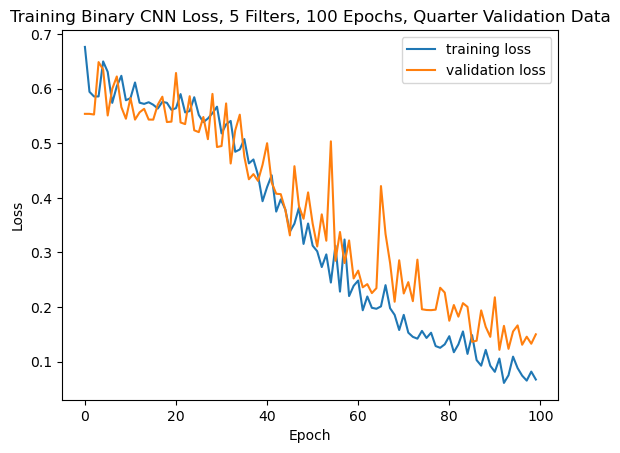

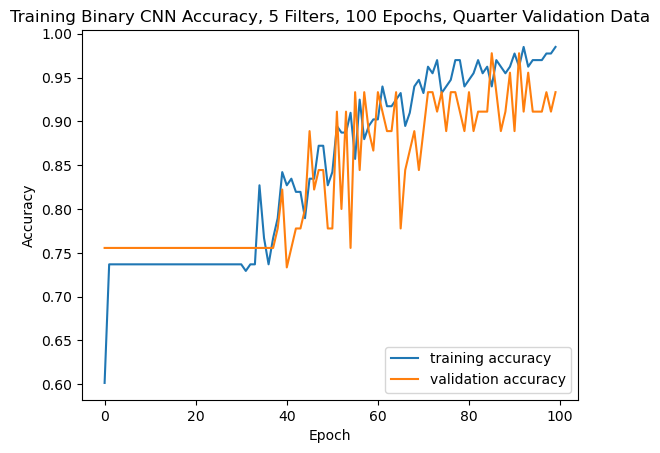

In [286]:
clarifier = "5 Filters, 100 Epochs, Quarter Validation Data"

plt.plot(history_2cnn_5conv_100ep_quartval.history['loss'])
plt.plot(history_2cnn_5conv_100ep_quartval.history['val_loss'])
plt.title('Training Binary CNN Loss, ' +  clarifier)
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['training loss', 'validation loss'], loc='upper right')
plt.show();

plt.plot(history_2cnn_5conv_100ep_quartval.history['accuracy'])
plt.plot(history_2cnn_5conv_100ep_quartval.history['val_accuracy'])
plt.title('Training Binary CNN Accuracy, ' +  clarifier)
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['training accuracy', 'validation accuracy'], loc='lower right')
plt.show();

In [287]:
model_2cnn_5conv_100ep_quartval_train_pred = model_2cnn_5conv_100ep_quartval.predict(X2_train, verbose = 0)
model_2cnn_5conv_100ep_quartval_train_class_pred = (model_2cnn_5conv_100ep_quartval_train_pred > .5).astype(int).flatten()

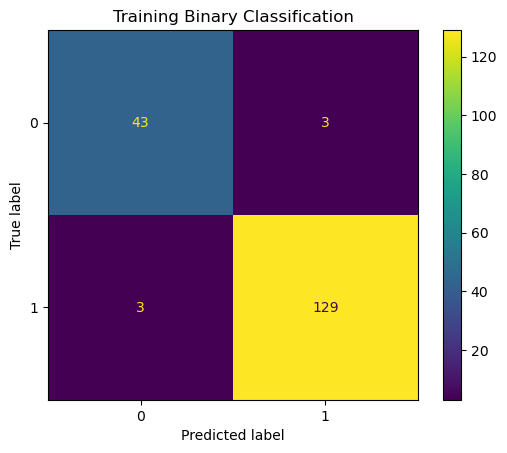

In [288]:
ConfusionMatrixDisplay(confusion_matrix(y2_train, model_2cnn_5conv_100ep_quartval_train_class_pred)).plot()
plt.title('Training Binary Classification')
plt.show()

In [289]:
model_2cnn_5conv_100ep_quartval_test_pred = model_2cnn_5conv_100ep_quartval.predict(X2_test, verbose = 0)
model_2cnn_5conv_100ep_quartval_test_class_pred = (model_2cnn_5conv_100ep_quartval_test_pred > .5).astype(int).flatten()

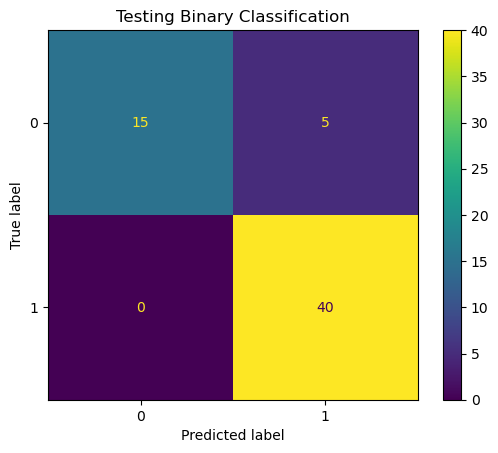

In [290]:
ConfusionMatrixDisplay(confusion_matrix(y2_test, model_2cnn_5conv_100ep_quartval_test_class_pred)).plot()
plt.title('Testing Binary Classification')
plt.show()

### Model Classification for 12 Species
We are attempting a convolution network in that these are adept at determining 2D features spatially by utilizing a kernel and sliding across our spectrograms.

In [297]:
model_12i_cnn_5conv_100ep_quartval = Sequential(
    [
    Conv2D(filters=4, kernel_size=(3,3), padding='same', activation='relu', input_shape=(128,517,1)), 
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=8, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=16, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dropout(rate=0.5),
    Dense(units=12, activation='softmax')
    ])

model_12i_cnn_5conv_100ep_quartval.compile(loss='binary_crossentropy',
              optimizer='rmsprop',
              metrics=['accuracy'])

model_12i_cnn_5conv_100ep_quartval.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_75 (Conv2D)              │ (None, 128, 517, 4)    │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_75 (MaxPooling2D) │ (None, 64, 258, 4)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_76 (Conv2D)              │ (None, 64, 258, 8)     │           296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_76 (MaxPooling2D) │ (None, 32, 129, 8)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_77 (Conv2D)              │ (None, 32, 129, 16)    │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_77 (MaxPooling2D) │ (None, 16, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_78 (Conv2D)              │ (None, 16, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_78 (MaxPooling2D) │ (None, 8, 32, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_79 (Conv2D)              │ (None, 8, 32, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_79 (MaxPooling2D) │ (None, 4, 16, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_20 (Flatten)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 12)             │        49,164 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 73,804 (288.30 KB)

 Trainable params: 73,804 (288.30 KB)

 Non-trainable params: 0 (0.00 B)

In [298]:
%%time

history_12i_cnn_5conv_100ep_quartval = model_12i_cnn_5conv_100ep_quartval.fit(X12i_train, y12i_train,
    epochs=100,  #repeat attempts over full dataset
    batch_size=64, #number of sample images used per gradient update in the back propogation after measuring loss
    validation_split=0.25 #this is the amount of our training data that we are checking our loss against
    ,verbose=0 #don't print anything
    )

CPU times: total: 7min 11s
Wall time: 1min 34s


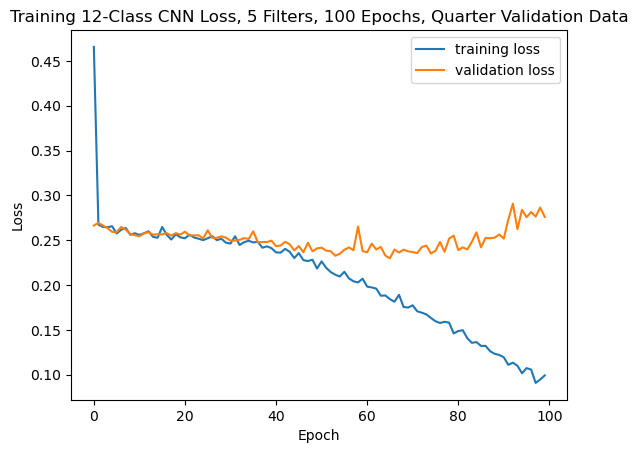

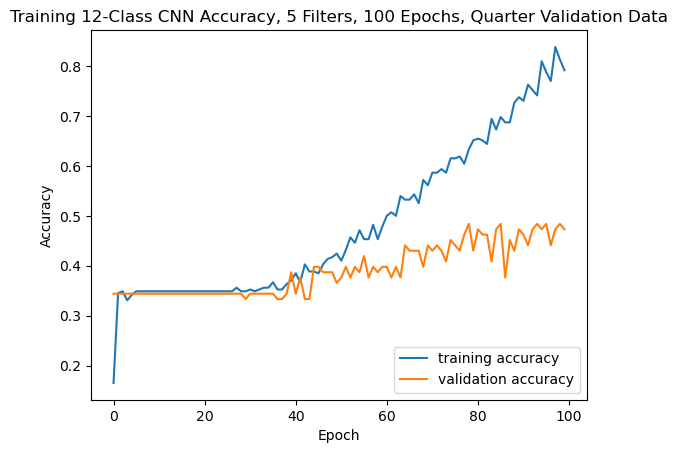

In [299]:
clarifier = "5 Filters, 100 Epochs, Quarter Validation Data"

plt.plot(history_12i_cnn_5conv_100ep_quartval.history['loss'])
plt.plot(history_12i_cnn_5conv_100ep_quartval.history['val_loss'])
plt.title('Training 12-Class CNN Loss, ' +  clarifier)
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['training loss', 'validation loss'], loc='upper right')
plt.show();

plt.plot(history_12i_cnn_5conv_100ep_quartval.history['accuracy'])
plt.plot(history_12i_cnn_5conv_100ep_quartval.history['val_accuracy'])
plt.title('Training 12-Class CNN Accuracy, ' +  clarifier)
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['training accuracy', 'validation accuracy'], loc='lower right')
plt.show();

In [306]:
model_12i_cnn_3conv_100ep_quartval_mp3 = Sequential(
    [
    Conv2D(filters=16, kernel_size=(3,3), padding='same', activation='relu', input_shape=(128,517,1)), 
    MaxPooling2D(pool_size=(3,3)),
    Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(3,3)),
    Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(3,3)),
    Flatten(),
    Dropout(rate=0.5),
    Dense(units=12, activation='softmax')
    ])

model_12i_cnn_3conv_100ep_quartval_mp3.compile(loss='binary_crossentropy',
              optimizer='rmsprop',
              metrics=['accuracy'])

model_12i_cnn_3conv_100ep_quartval_mp3.summary()

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_90 (Conv2D)              │ (None, 128, 517, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_90 (MaxPooling2D) │ (None, 42, 172, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_91 (Conv2D)              │ (None, 42, 172, 32)    │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_91 (MaxPooling2D) │ (None, 14, 57, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_92 (Conv2D)              │ (None, 14, 57, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_92 (MaxPooling2D) │ (None, 4, 19, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_25 (Flatten)            │ (None, 4864)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 4864)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 12)             │        58,380 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,676 (319.05 KB)

 Trainable params: 81,676 (319.05 KB)

 Non-trainable params: 0 (0.00 B)

In [307]:
%%time

history_12i_cnn_3conv_100ep_quartval_mp3 = model_12i_cnn_3conv_100ep_quartval_mp3.fit(X12i_train, y12i_train,
    epochs=100,  #repeat attempts over full dataset
    batch_size=64, #number of sample images used per gradient update in the back propogation after measuring loss
    validation_split=0.25 #this is the amount of our training data that we are checking our loss against
    ,verbose=0 #don't print anything
    )

CPU times: total: 11min 43s
Wall time: 2min 6s


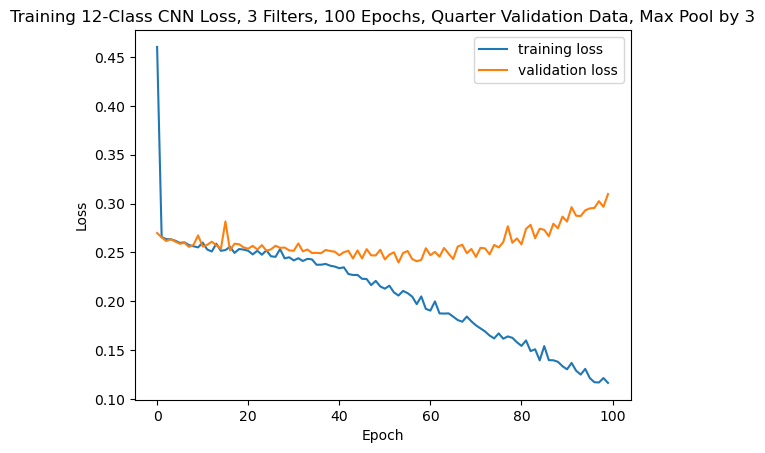

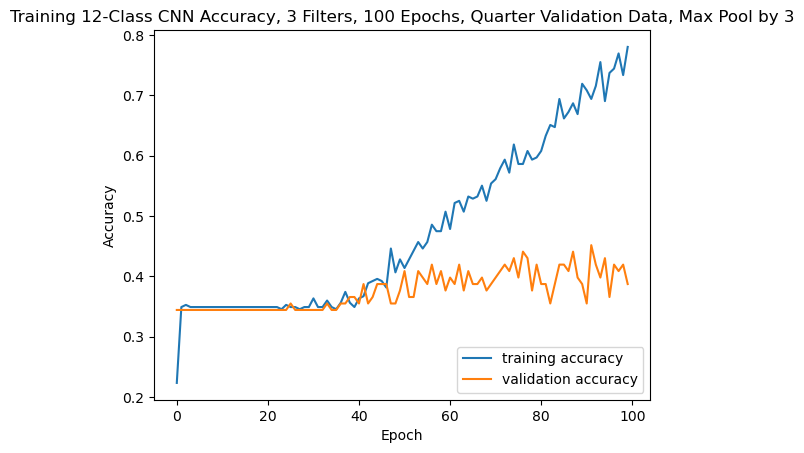

In [308]:
clarifier = "3 Filters, 100 Epochs, Quarter Validation Data, Max Pool by 3"

plt.plot(history_12i_cnn_3conv_100ep_quartval_mp3.history['loss'])
plt.plot(history_12i_cnn_3conv_100ep_quartval_mp3.history['val_loss'])
plt.title('Training 12-Class CNN Loss, ' +  clarifier)
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['training loss', 'validation loss'], loc='upper right')
plt.show();

plt.plot(history_12i_cnn_3conv_100ep_quartval_mp3.history['accuracy'])
plt.plot(history_12i_cnn_3conv_100ep_quartval_mp3.history['val_accuracy'])
plt.title('Training 12-Class CNN Accuracy, ' +  clarifier)
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['training accuracy', 'validation accuracy'], loc='lower right')
plt.show();

In [313]:
model_12i_cnn_3conv64_100ep_quartval_mp2_gap = Sequential(
    [
    Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu', input_shape=(128,517,1)), 
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    GlobalAveragePooling2D(),
    Dropout(rate=0.5),
    Dense(units=12, activation='softmax')
    ])

model_12i_cnn_3conv64_100ep_quartval_mp2_gap.compile(loss='binary_crossentropy',
              optimizer='rmsprop',
              metrics=['accuracy'])

model_12i_cnn_3conv64_100ep_quartval_mp2_gap.summary()

Model: "sequential_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_102 (Conv2D)             │ (None, 128, 517, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_102               │ (None, 64, 258, 64)    │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_103 (Conv2D)             │ (None, 64, 258, 64)    │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_103               │ (None, 32, 129, 64)    │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_104 (Conv2D)             │ (None, 32, 129, 64)    │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_104               │ (None, 16, 64, 64)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 12)             │           780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,276 (294.05 KB)

 Trainable params: 75,276 (294.05 KB)

 Non-trainable params: 0 (0.00 B)

In [316]:
%%time

history_12i_cnn_3conv64_100ep_quartval_mp2_gap = model_12i_cnn_3conv64_100ep_quartval_mp2_gap.fit(X12i_train, y12i_train,
    epochs=100,  #repeat attempts over full dataset
    batch_size=64, #number of sample images used per gradient update in the back propogation after measuring loss
    validation_split=0.25 #this is the amount of our training data that we are checking our loss against
    #,verbose=1 #don't print anything
    )

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.1295 - loss: 0.3523 - val_accuracy: 0.3441 - val_loss: 0.2769
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.2302 - loss: 0.3342 - val_accuracy: 0.3441 - val_loss: 0.2752
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.1691 - loss: 0.3294 - val_accuracy: 0.3441 - val_loss: 0.2751
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.2410 - loss: 0.3156 - val_accuracy: 0.3441 - val_loss: 0.2687
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.2914 - loss: 0.3055 - val_accuracy: 0.3441 - val_loss: 0.2647
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.2302 - loss: 0.3114 - val_accuracy: 0.3441 - val_loss: 0.2717
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.2266 - loss: 0.3057 - val_accuracy: 0.3441 - val_loss: 0.2636
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.2518 - loss: 0.3066 - val_accuracy: 0.3441 - val_loss: 0.2716
